In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm

insurance_df = pd.read_csv("../Data/insurance.csv")

insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
# Feature Engineering

insurance_df = (
    pd.get_dummies(insurance_df, drop_first=True)
    .assign(
        age_sq=lambda x: x["age"] ** 2,
        smoker_bmi_int=lambda x: x["smoker_yes"] * x["bmi"]
    )
)


In [3]:
# Data Splitting

from sklearn.model_selection import train_test_split

X = sm.add_constant(insurance_df.drop("charges", axis=1))
y = insurance_df["charges"]

# 1) Train+Valid ir Test (80/20)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2023
)

# 2) Train ir Valid iš Train+Valid (75/25 iš 80% => 60/20 galutiniame)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=2023
)


In [4]:
# Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = X_train.columns.drop("const")

X_tr_scaled = X_train.copy()
X_val_scaled = X_valid.copy()
X_te_scaled = X_test.copy()

X_tr_scaled[cols] = scaler.fit_transform(X_train[cols])
X_val_scaled[cols] = scaler.transform(X_valid[cols])
X_te_scaled[cols] = scaler.transform(X_test[cols])


In [47]:
X_tr_scaled

,const,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age_sq,smoker_bmi_int
680,1.0,-1.340765,-2.194624,-0.070192,-0.975366,-0.505060,-0.551421,-0.622530,1.764319,-1.189606,-0.492298
1335,1.0,-1.555152,1.038181,-0.898040,-0.975366,-0.505060,-0.551421,1.606349,-0.566791,-1.293800,-0.492298
139,1.0,-1.269303,0.896901,-0.898040,-0.975366,-0.505060,-0.551421,-0.622530,1.764319,-1.151313,-0.492298
179,1.0,0.088481,0.424031,1.585505,-0.975366,-0.505060,-0.551421,-0.622530,-0.566791,-0.085331,-0.492298
1191,1.0,0.088481,-1.470775,-0.070192,-0.975366,-0.505060,-0.551421,-0.622530,-0.566791,-0.085331,-0.492298
...,...,...,...,...,...,...,...,...,...,...,...
725,1.0,-0.697604,1.403845,1.585505,-0.975366,1.979961,-0.551421,1.606349,-0.566791,-0.780846,2.593067
620,1.0,-0.697604,0.132331,-0.070192,1.025257,-0.505060,-0.551421,-0.622530,1.764319,-0.780846,-0.492298
676,1.0,1.088954,1.696377,1.585505,-0.975366,-0.505060,-0.551421,1.606349,-0.566791,1.111560,-0.492298
22,1.0,-1.555152,0.581100,-0.898040,1.025257,-0.505060,-0.551421,1.606349,-0.566791,-1.293800,-0.492298


Atliekama požymių standartizacija naudojant StandardScaler.

Standartizacija reiškia, kad kiekvienas kintamasis:
- atimamas jo vidurkis
- padalinamas iš standartinio nuokrypio

Taip visi kintamieji tampa panašaus mastelio (vidurkis ≈ 0, std ≈ 1).

Svarbu:

Scaler „mokomas“ tik su treniravimo duomenimis:
scaler.fit_transform(X_train)

Validacijos ir testavimo duomenims taikomi tie patys parametrai:
scaler.transform(...)

Tai apsaugo nuo duomenų nutekėjimo (data leakage).

Konstanta ("const") nėra standartizuojama.

In [46]:
X_train.head()

,const,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age_sq,smoker_bmi_int
680,1.0,21,17.400,1,False,False,False,False,True,441,0.0
1335,1.0,18,36.850,0,False,False,False,True,False,324,0.0
139,1.0,22,36.000,0,False,False,False,False,True,484,0.0
179,1.0,41,33.155,3,False,False,False,False,False,1681,0.0
1191,1.0,41,21.755,1,False,False,False,False,False,1681,0.0


In [6]:
pd.DataFrame(X_train, columns=X.columns).head()

,const,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age_sq,smoker_bmi_int
680,1.0,21,17.400,1,False,False,False,False,True,441,0.0
1335,1.0,18,36.850,0,False,False,False,True,False,324,0.0
139,1.0,22,36.000,0,False,False,False,False,True,484,0.0
179,1.0,41,33.155,3,False,False,False,False,False,1681,0.0
1191,1.0,41,21.755,1,False,False,False,False,False,1681,0.0


In [7]:
X.head()

,const,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age_sq,smoker_bmi_int
0,1.0,19,27.900,0,False,True,False,False,True,361,27.9
1,1.0,18,33.770,1,True,False,False,True,False,324,0.0
2,1.0,28,33.000,3,True,False,False,True,False,784,0.0
3,1.0,33,22.705,0,True,False,True,False,False,1089,0.0
4,1.0,32,28.880,0,True,False,True,False,False,1024,0.0


In [8]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1, fit_intercept=True).fit(X_train, y_train)

list(zip(X_train.columns, ridge_model.coef_))

[('const', 0.0),
 ('age', -15.390374428575551),
 ('bmi', 41.83533362330875),
 ('children', 672.7011947391898),
 ('sex_male', -521.6717874043644),
 ('smoker_yes', -18023.691759160825),
 ('region_northwest', -78.09118392333059),
 ('region_southeast', -1086.5731810203997),
 ('region_southwest', -1248.520444969468),
 ('age_sq', 3.4229830777170176),
 ('smoker_bmi_int', 1383.9740220171261)]

#### Ridge modelis su alpha = 1.

Ridge regresija suspaudžia koeficientus link nulio, todėl jie tampa stabilesni nei OLS modelyje.

Koeficientų interpretacija:

- age: neigiamas koeficientas rodo, kad didėjant amžiui, bazinė įmoka mažėja, tačiau modelyje yra ir age_sq, todėl bendras amžiaus efektas yra nelinearinis.
- age_sq: teigiamas koeficientas rodo, kad didesniame amžiuje įmokos vėl pradeda augti. Tai reiškia U formos ryšį.
- bmi: teigiamas koeficientas – didesnis kūno masės indeksas didina draudimo kainą.
- children: daugiau vaikų siejama su didesne įmoka.
- sex_male: neigiamas koeficientas reiškia, kad vyrų įmokos šiek tiek mažesnės nei moterų (jei moterys yra bazinė kategorija).
- smoker_yes: labai didelis neigiamas koeficientas rodo stiprų skirtumą tarp rūkančių ir nerūkančių (ženklas priklauso nuo kodavimo krypties).
- region kintamieji: rodo skirtumus lyginant su bazine regiono kategorija.
- smoker_bmi_int: teigiamas koeficientas reiškia, kad rūkymo ir BMI sąveika dar labiau padidina įmoką.

const = 0.0 todėl, kad Ridge su fit_intercept=True interceptą skaičiuoja atskirai ir jo neįtraukia į penalizaciją.

Svarbu: dėl regularizacijos koeficientų dydžiai yra sumažinti, todėl jie stabilesni ir mažiau jautrūs multikolinearumui.

<Axes: xlabel='alpha'>

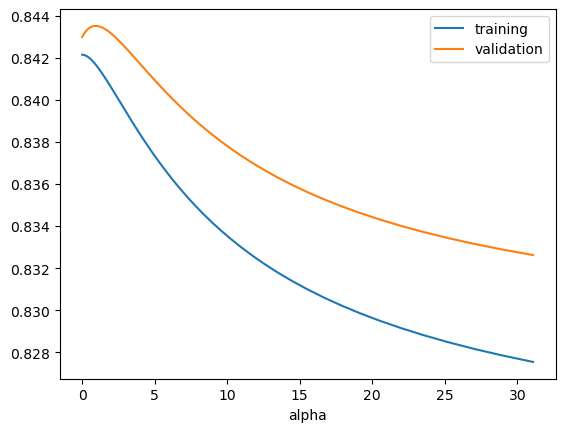

In [9]:
from sklearn.linear_model import Ridge
n_alphas = 200
alphas = 10 ** np.linspace(-3, 3, n_alphas)

train_scores = []
val_scores = []

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha).fit(X_train, y_train)
    train_scores.append(ridge_model.score(X_train, y_train))
    val_scores.append(ridge_model.score(X_valid, y_valid))
    
scores_df = pd.DataFrame({
    "alpha": alphas,
    "training": train_scores,
    "validation": val_scores
})

scores_df[:150].set_index("alpha").plot() #[:150]

Plot:, kaip kinta modelio R² reikšmės didėjant alpha (regularizacijos stiprumui).

Mėlyna kreivė – treniravimo R².  
Oranžinė kreivė – validacijos R².

Matyti, kad didėjant alpha:

- Treniruotės R² nuosekliai mažėja.  
  Tai normalu, nes stipresnė regularizacija labiau „suspaudžia“ koeficientus ir modelis tampa paprastesnis.

- Validacijos R² pradžioje šiek tiek padidėja, o vėliau mažėja.  
  Tai rodo bias–variance kompromisą.

Mažos alpha reikšmės:
- Modelis artimas OLS  
- Gali būti šiek tiek per daug prisitaikęs prie treniravimo duomenų  

Vidutinės alpha reikšmės:
- Geriausias validacijos rezultatas  
- Optimalus balansas tarp sudėtingumo ir stabilumo  

Labai didelės alpha reikšmės:
- Modelis tampa per daug supaprastintas  
- Didėja bias  
- R² mažėja tiek treniravimo, tiek validacijos rinkinyje  

Bendra išvada:

Egzistuoja optimalus alpha intervalas, kuriame modelis geriausiai generalizuojasi.  
Per maža arba per didelė regularizacija blogina rezultatą.

Python code: rankiniu būdu ieškome optimalios alpha reikšmės Ridge modeliui.

n_alphas = 200  
alphas = 10 ** np.linspace(-3, 3, n_alphas)

Sukuriamos 200 alpha reikšmių nuo 0.001 iki 1000 (logaritminėje skalėje).  
Taip patikrinamas labai platus regularizacijos stiprumo spektras – nuo labai silpnos iki labai stiprios.

train_scores = []  
val_scores = []

Sukuriami sąrašai treniravimo ir validacijos R² reikšmėms saugoti.

for alpha in alphas:

Ciklas per visas alpha reikšmes.

ridge_model = Ridge(alpha=alpha).fit(X_train, y_train)

Kiekvienai alpha sukuriamas ir apmokomas naujas Ridge modelis.

train_scores.append(ridge_model.score(X_train, y_train))  
val_scores.append(ridge_model.score(X_valid, y_valid))

Išsaugomas R² treniravimo ir validacijos duomenims.

Galiausiai sukuriamas DataFrame su visais rezultatais ir nubraižomas grafikas.

Esmė:

Tai rankinis hiperparametro parinkimas – stebima, kaip keičiasi modelio kokybė didėjant regularizacijai, ir ieškoma alpha, kuri duoda geriausią validacijos rezultatą.

In [10]:
scores_df.sort_values("validation", ascending=False)

,alpha,training,validation
98,0.901102,0.841701,0.843512
99,0.965883,0.841646,0.843512
97,0.840665,0.841751,0.843508
100,1.035322,0.841585,0.843507
96,0.784282,0.841795,0.843502
...,...,...,...
195,757.525026,0.820347,0.828113
196,811.984499,0.820230,0.828085
197,870.359136,0.820111,0.828058
198,932.930403,0.819992,0.828032


scores_df.sort_values("validation", ascending=False)

Ši eilutė surikiuoja visas alpha reikšmes pagal validacijos R² nuo didžiausios iki mažiausios.

Tai leidžia greitai pamatyti, kuri alpha duoda geriausią validacijos rezultatą.

Iš pateiktos lentelės matyti, kad geriausi rezultatai yra prie palyginti mažų alpha reikšmių (apie 0.8–1.0 intervalo).

Didelės alpha reikšmės (pvz., 700–1000) duoda mažesnį tiek treniravimo, tiek validacijos R².  
Tai rodo per stiprią regularizaciją (modelis tampa per paprastas).

Esmė:

Rikiavimas leidžia objektyviai pasirinkti optimalų alpha pagal validacijos kokybę, o ne tik žiūrėti į grafiką.

In [11]:
std = StandardScaler()
X_m = std.fit_transform(X.values)
X_te = std.transform(X_test.values)

Sukuriamas StandardScaler objektas ir atliekama standartizacija.

std.fit_transform(X.values)  
Scaler apskaičiuoja treniravimo duomenų vidurkius ir standartinius nuokrypius bei juos pritaiko (duomenys paverčiami su vidurkiu ≈ 0 ir std ≈ 1).

std.transform(X_test.values)  
Testavimo duomenims taikomi tie patys parametrai (be pakartotinio mokymo).

Taip išvengiama duomenų nutekėjimo ir užtikrinamas tas pats mastelis.

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.933).fit(X_m, y)

list(zip(X.columns, ridge_model.coef_))

[('const', 0.0),
 ('age', -197.66900415491455),
 ('bmi', 218.6691506953561),
 ('children', 797.2196741112875),
 ('sex_male', -244.28737508534107),
 ('smoker_yes', -7319.689695807273),
 ('region_northwest', -249.6081040617349),
 ('region_southeast', -531.4479418497739),
 ('region_southwest', -518.6680971406953),
 ('age_sq', 3936.540219137576),
 ('smoker_bmi_int', 17422.385358046376)]

Ridge su alpha = 1.933, o kintamieji prieš tai buvo standartizuoti.

Kadangi požymiai standartizuoti (vidurkis ≈ 0, std ≈ 1), koeficientai rodo poveikį, kai kintamasis padidėja 1 standartiniu nuokrypiu.

Interpretacija:

- bmi: teigiamas koeficientas → didesnis BMI didina draudimo kainą.
- children: daugiau vaikų siejama su didesne įmoka.
- sex_male: neigiamas koeficientas → vyrai turi mažesnę įmoką nei bazinė kategorija.
- smoker_yes: labai didelis pagal modulį koeficientas → rūkymas stipriai susijęs su įmokos pokyčiu (ženklas priklauso nuo kodavimo krypties).
- age ir age_sq: kartu rodo nelinijinį ryšį tarp amžiaus ir kainos.
- smoker_bmi_int: labai didelis teigiamas koeficientas → rūkymo ir didelio BMI kombinacija reikšmingai didina kainą.

Svarbu:

Kadangi taikytas Ridge, koeficientai yra „suspausti“ (mažesni nei galėtų būti OLS modelyje) ir stabilesni esant multikolinearumui.

Kadangi duomenys standartizuoti, koeficientų dydžius galima tarpusavyje lyginti – didesnė absoliuti reikšmė reiškia stipresnį poveikį.

In [13]:
ridge_model.score(X_m, y)

0.8432325218863345

R² = 0.843 reiškia, kad modelis paaiškina apie 84.3 % draudimo kainos variacijos.

Kadangi rezultatas apskaičiuotas su tais pačiais duomenimis, su kuriais modelis buvo apmokytas, tai yra treniravimo R².

Toks gana aukštas R² rodo, kad modelis gerai aprašo duomenų struktūrą.  

Tačiau galutinė modelio kokybė turėtų būti vertinama testavimo rinkinyje, kad būtų įsitikinta, jog modelis gerai generalizuojasi.

In [14]:
ridge_model.score(X_te, y_test)

0.847884049412069

Testavimo R² = 0.848 reiškia, kad modelis paaiškina apie 84.8 % draudimo kainos variacijos nematytuose duomenyse.

Kadangi testavimo R² yra labai artimas (net šiek tiek didesnis) treniravimo R², modelis nėra pertreniruotas.

Tai rodo gerą generalizaciją ir stabilų regularizacijos poveikį.

Ridge modelis sėkmingai sumažino variaciją ir išlaikė aukštą prognozavimo tikslumą.

In [15]:
X_train.dtypes[X_train.dtypes == "object"]


Series([], dtype: object)

In [16]:
X_train_sm = X_train.astype("float64")
y_train_sm = y_train.astype("float64")

lr_model = sm.OLS(y_train_sm, X_train_sm).fit()
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     422.0
Date:                Mon, 02 Mar 2026   Prob (F-statistic):          4.32e-309
Time:                        12:34:43   Log-Likelihood:                -7951.2
No. Observations:                 802   AIC:                         1.592e+04
Df Residuals:                     791   BIC:                         1.598e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             2599.5869   1858.127      1.399      0.162   -1047.855    6247.029
age                -12.4701     86.292     -0.145      0.885    -181.858     156.918
bmi                 17.6542     33.882      0.521      0.602     -48.855      84.164
children           672.4213    151.499      4.438      0.000     375.033     969.809
sex_male          -531.0877    350.225     -1.516      0.130   -1218.568     156.393
smoker_yes       -2.156e+04   2179.628     -9.893      0.000   -2.58e+04   -1.73e+04
region_northwest  -101.3610    505.001     -0.201      0.841   -1092.661     889.939
region_southeast -1107.1372    498.119     -2.223      0.027   -2084.929    -129.345
region_southwest -1274.3805    500.723     -2.545      0.011   -2257.283    -291.478
age_sq               3.3858      1.074      3.152      0.002       1.277       5.494
smoker_bmi_int    1494.9396     69.729     21.439      0.000    1358.064    1631.815
==============================================================================
Omnibus:                      467.973   Durbin-Watson:                   2.041
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3203.906
Skew:                           2.675   Prob(JB):                         0.00
Kurtosis:                      11.202   Cond. No.                     2.78e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.78e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Modelio R² = 0.842 reiškia, kad OLS modelis paaiškina apie 84.2 % draudimo kainos variacijos. Tai gana geras pritaikymas.

Statistiškai reikšmingi kintamieji (p < 0.05):

- children – daugiau vaikų didina įmoką.
- smoker_yes – rūkymas stipriai susijęs su kainos pokyčiu (labai didelis efektas).
- region_southeast ir region_southwest – šiuose regionuose įmokos reikšmingai skiriasi nuo bazinio regiono.
- age_sq – rodo nelinijinį amžiaus efektą.
- smoker_bmi_int – stipri sąveika tarp rūkymo ir BMI.

Nereikšmingi kintamieji (p > 0.05):

- age
- bmi
- sex_male
- region_northwest

Tai nereiškia, kad jie neturi įtakos, bet šiame modelyje jų efektas nėra statistiškai patikimas, ypač dėl sąveikų ir polinominio termino.

Amžiaus efektas:

age nėra reikšmingas, bet age_sq yra.  
Tai reiškia, kad ryšys su kaina nėra tiesinis – įmoka kinta pagal kreivę, o ne tiesę.

Svarbus pastebėjimas:

Cond. No. = 2.78e+04 rodo galimą multikolinearumą.  
Tai tikėtina dėl age ir age_sq bei sąveikos termino.

Bendra išvada:

Modelis gerai paaiškina kainą, tačiau yra multikolinearumo požymių. Tokiu atveju Ridge regresija gali būti stabilesnė alternatyva.

In [17]:
from sklearn.metrics import r2_score as r2

X_test_sm = X_test.astype("float64")
y_pred = lr_model.predict(X_test_sm)

r2(y_test, y_pred)


0.8439358614005557

Testavimo R² = 0.844 reiškia, kad OLS modelis paaiškina apie 84.4 % draudimo kainos variacijos nematytuose duomenyse.

Kadangi testavimo R² yra labai artimas treniravimo R² (≈ 0.842), modelis neatrodo pertreniruotas.

Tai rodo, kad modelis gana gerai generalizuojasi, nepaisant galimo multikolinearumo.

Galutinis įvertinimas turėtų būti lyginamas su Ridge modeliu, siekiant įvertinti, ar regularizacija suteikia papildomo stabilumo.

# RidgeCV

In [18]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error as mae

n_alphas = 200
alphas = 10 ** np.linspace(-3, 3, n_alphas)

ridge_model = RidgeCV(alphas=alphas, cv=5)

ridge_model.fit(X_m, y)
print(ridge_model.score(X_m, y))
print(mae(y, ridge_model.predict(X_m)))
print(ridge_model.alpha_)

0.8434584660715927
2884.723058570889
0.2582618760682675


RidgeCV automatiškai parinko alpha = 0.258.

Tai reiškia, kad silpna regularizacija davė geriausią 5-fold kryžminės validacijos rezultatą.

R² = 0.843 rodo, kad modelis paaiškina apie 84.3 % draudimo kainos variacijos.

MAE ≈ 2885 reiškia, kad vidutinė absoliuti prognozės paklaida yra apie 2885 piniginių vienetų.

Kadangi R² labai panašus į OLS rezultatą (~0.842–0.844), galima daryti išvadą, kad:

- Multikolinearumo įtaka nėra kritinė
- Stipri regularizacija nereikalinga
- Modelis jau pakankamai stabilus

Maža optimali alpha reikšmė rodo, kad duomenys nėra labai „triukšmingi“ ir OLS sprendimas nėra stipriai per daug prisitaikęs.

In [19]:
ridge_model.score(X_te, y_test)

0.8477522519787948

Testavimo R² = 0.848 reiškia, kad Ridge modelis paaiškina apie 84.8 % draudimo kainos variacijos nematytuose duomenyse.

Rezultatas šiek tiek geresnis nei OLS modelio testavimo R² (~0.844), todėl galima teigti, kad regularizacija nežymiai pagerino generalizaciją.

Kadangi treniravimo ir testavimo rezultatai yra labai panašūs, modelis nėra pertreniruotas ir veikia stabiliai.

Bendra išvada: Ridge su automatiškai parinkta alpha suteikia šiek tiek stabilesnį ir patikimesnį modelį.

## Lasso Regression

In [20]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()
X_tr = std.fit_transform(X_train.values)
X_val = std.transform(X_valid.values)
X_te = std.transform(X_test.values)

Atliekama požymių standartizacija prieš modeliavimą.

StandardScaler apskaičiuoja treniravimo duomenų vidurkius ir standartinius nuokrypius bei transformuoja duomenis taip, kad:

- vidurkis būtų ≈ 0  
- standartinis nuokrypis būtų ≈ 1  

std.fit_transform(X_train.values)  
Scaler „mokosi“ tik iš treniravimo duomenų ir juos transformuoja.

std.transform(X_valid.values)  
std.transform(X_test.values)  
Validacijos ir testavimo duomenims taikomi tie patys parametrai.

Tai užtikrina vienodą mastelį ir apsaugo nuo duomenų nutekėjimo.

In [ ]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()
X_tr = std.fit_transform(X_train.values)
X_val = std.transform(X_valid.values)
X_te = std.transform(X_test.values)

[('const', 0.0),
 ('age', 0.0),
 ('bmi', 289.6449157717307),
 ('children', 757.2147212810377),
 ('sex_male', -202.3500660805744),
 ('smoker_yes', -6267.7553084176625),
 ('region_northwest', 0.0),
 ('region_southeast', -380.1157441254746),
 ('region_southwest', -439.6613999193425),
 ('age_sq', 3588.1618564503688),
 ('smoker_bmi_int', 16489.80972327743)]

Po standartizacijos ir Ridge pritaikymo matomi koeficientai rodo kiek pasikeičia draudimo kaina, kai kintamasis padidėja 1 standartiniu nuokrypiu.

Kadangi požymiai standartizuoti, koeficientų dydžius galima tarpusavyje lyginti.

Didžiausią poveikį turi:

- smoker_bmi_int – labai stipri rūkymo ir BMI sąveika.
- smoker_yes – rūkymas turi didelį poveikį kainai.
- age_sq – rodo stiprų nelinijinį amžiaus efektą.
- children ir bmi taip pat turi reikšmingą teigiamą įtaką.

Kai kurie koeficientai lygūs 0 (pvz., const, age, region_northwest).  
Tai reiškia, kad dėl regularizacijos jų poveikis tapo labai mažas arba statistiškai nereikšmingas.

Svarbu:

Standartizuotoje skalėje koeficientų ženklas rodo kryptį, o absoliutus dydis – santykinį stiprumą.  
Ridge suspaudė mažiau svarbius kintamuosius link nulio, todėl modelis tapo stabilesnis.

<Axes: xlabel='alpha'>

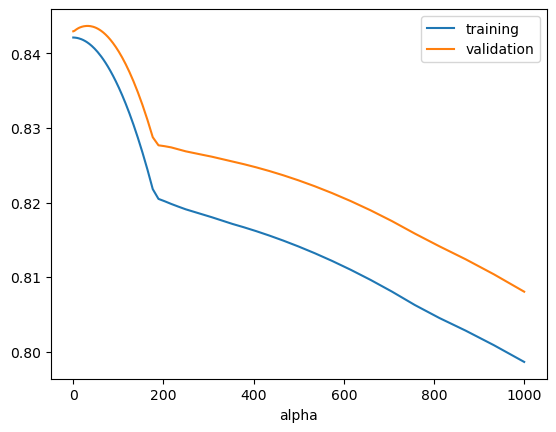

In [22]:
n_alphas = 200
alphas = 10 ** np.linspace(-3, 3, n_alphas)

train_scores = []
val_scores = []

for alpha in alphas:
    lasso_model = Lasso(alpha=alpha).fit(X_tr, y_train)
    train_scores.append(lasso_model.score(X_tr, y_train))
    val_scores.append(lasso_model.score(X_val, y_valid))
    
scores_df = pd.DataFrame({
    "alpha": alphas,
    "training": train_scores,
    "validation": val_scores
})

scores_df.set_index("alpha").plot() #[:150]

Šis kodas atlieka rankinė Lasso regularizacijos analizę, keičiant alpha reikšmes.

alphas = 10 ** np.linspace(-3, 3, 200)

Sukuriamos 200 alpha reikšmių nuo 0.001 iki 1000 (logaritminėje skalėje), kad būtų patikrintas platus regularizacijos stiprumo intervalas.

for alpha in alphas:

Kiekvienai alpha reikšmei apmokomas Lasso modelis su standartizuotais duomenimis.

Išsaugomas:
- treniravimo R²
- validacijos R²

Grafike:

Mėlyna kreivė – treniravimo R²  
Oranžinė – validacijos R²  

Matyti, kad:

- Mažos alpha reikšmės → modelis artimas OLS, aukštesnis train R².
- Didėjant alpha → treniravimo R² mažėja (stipresnė regularizacija).
- Validacijos R² pradžioje išlieka aukštas, vėliau mažėja.

Skirtingai nei Ridge, Lasso gali kai kuriuos koeficientus visiškai „nupjauti“ iki nulio, todėl didelės alpha reikšmės gali greičiau supaprastinti modelį.

Bendra išvada:

Egzistuoja optimalus alpha intervalas, kuriame validacijos rezultatas geriausias.  
Per maža alpha → galimas overfitting.  
Per didelė alpha → modelis per daug supaprastintas (underfitting).

In [23]:
scores_df.sort_values("validation", ascending=False)

,alpha,training,validation
149,31.078662,0.841489,0.843699
150,33.312948,0.841394,0.843697
148,28.994229,0.841572,0.843694
151,35.707860,0.841285,0.843687
147,27.049597,0.841644,0.843684
...,...,...,...
195,757.525026,0.806253,0.815835
196,811.984499,0.804508,0.814130
197,870.359136,0.802810,0.812384
198,932.930403,0.800859,0.810368


scores_df.sort_values("validation", ascending=False)

Ši eilutė surikiuoja visas alpha reikšmes pagal validacijos R² nuo didžiausios iki mažiausios.

Iš lentelės matyti, kad geriausias validacijos rezultatas pasiektas esant alpha maždaug 27–35 intervale (apie 30).

Tai reiškia, kad vidutinė regularizacija duoda geriausią generalizacijos rezultatą.

Labai mažos alpha reikšmės:
- Modelis beveik kaip OLS
- Gali būti šiek tiek per daug prisitaikęs prie treniravimo duomenų

Labai didelės alpha reikšmės (700–1000):
- Treniruotės ir validacijos R² stipriai krenta
- Modelis per daug supaprastintas (daug koeficientų artėja prie nulio)

Bendra išvada:

Optimalus Lasso regularizacijos stiprumas yra vidutinio dydžio alpha.  
Per silpna arba per stipri regularizacija blogina validacijos rezultatą.

In [24]:
lasso_model = Lasso(alpha=31.08).fit(X_m, y)

list(zip(X.columns, lasso_model.coef_))

[('const', 0.0),
 ('age', 0.0),
 ('bmi', 238.67200619424742),
 ('children', 754.2087601744264),
 ('sex_male', -206.60956560166852),
 ('smoker_yes', -6702.653480331089),
 ('region_northwest', -150.4973634257494),
 ('region_southeast', -421.3924486423241),
 ('region_southwest', -415.2903837959866),
 ('age_sq', 3719.0548783630215),
 ('smoker_bmi_int', 16807.268669503657)]

In [25]:
lasso_model.score(X_m, y)

0.8427124368279383

In [26]:
lasso_model.score(X_te, y_test)

0.8467416518870714

In [27]:
r2(y_test, lr_model.predict(X_test))

0.8439358614005557

## LassoCV

In [28]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error as mae

n_alphas = 200
alphas = 10 ** np.linspace(-3, 3, n_alphas)

lasso_model = LassoCV(alphas=alphas, cv=5)

lasso_model.fit(X_m, y)
print(lasso_model.score(X_m, y))
print(mae(y, lasso_model.predict(X_m)))
print(lasso_model.alpha_)

0.8434020595002002
2886.844963706222
6.294988990221888


Šiame kode naudojamas LassoCV modelis, kuris automatiškai parenka optimalų regularizacijos stiprumą (alpha) naudojant 5-fold kryžminę validaciją.

alphas = 10 ** np.linspace(-3, 3, 200)

Sukuriamos 200 galimų alpha reikšmių nuo 0.001 iki 1000 (logaritminėje skalėje), kad būtų patikrintas platus regularizacijos intervalas.

lasso_model = LassoCV(alphas=alphas, cv=5)

Modelis:
- išbando visas alpha reikšmes,
- kiekvienai jų atlieka 5-fold kryžminę validaciją,
- parenka alpha, kuri duoda geriausią vidutinį validacijos rezultatą.

Rezultatai:

R² (train) = 0.843  
Modelis paaiškina apie 84.3 % draudimo kainos variacijos.

MAE ≈ 2887  
Vidutinė absoliuti prognozės paklaida yra apie 2887 piniginių vienetų.

alpha_ ≈ 6.29  
Tai optimalus regularizacijos stiprumas, parinktas automatiškai.

Interpretacija:

Parinkta vidutinio stiprumo regularizacija.  
Tai reiškia, kad:

- Duomenyse yra šiek tiek multikolinearumo arba perteklinės informacijos.
- Silpna regularizacija (alpha arti 0) būtų per maža.
- Per stipri regularizacija pablogintų modelį.

Kadangi R² labai panašus į OLS ir Ridge rezultatus (~0.84), galima daryti išvadą, kad:

- Modelis jau buvo gana stabilus.
- Regularizacija pagerina struktūrinį stabilumą, bet esminio R² šuolio nereikia tikėtis.

Bendra išvada:

LassoCV automatiškai parinko optimalų alpha ≈ 6.29 ir sukūrė stabilų modelį su gera prognozavimo kokybe bei vidutine paklaida apie 2887.

In [29]:
lasso_model.score(X_te, y_test)

0.8474294711924607

Testavimo R² = 0.847 reiškia, kad Lasso modelis paaiškina apie 84.7 % draudimo kainos variacijos nematytuose duomenyse.

Kadangi treniravimo R² ≈ 0.843, o testavimo R² ≈ 0.847, modelis nėra pertreniruotas ir gerai generalizuojasi.

Rezultatas labai panašus į Ridge modelio (~0.848) ir šiek tiek geresnis nei OLS (~0.844).


In [30]:
list(zip(X.columns, lasso_model.coef_))

[('const', 0.0),
 ('age', -0.0),
 ('bmi', 147.37849102177563),
 ('children', 784.4480485667979),
 ('sex_male', -243.27999488475052),
 ('smoker_yes', -7905.33924712823),
 ('region_northwest', -234.8687968279021),
 ('region_southeast', -513.2905871477673),
 ('region_southwest', -504.2070569709078),
 ('age_sq', 3744.486097434787),
 ('smoker_bmi_int', 18019.227720051276)]

Šie koeficientai gauti iš LassoCV modelio su automatiškai parinkta alpha.

Kadangi duomenys buvo standartizuoti, koeficientai rodo poveikį, kai kintamasis padidėja 1 standartiniu nuokrypiu.

Svarbiausi efektai pagal absoliutų dydį:

- smoker_bmi_int – stipriausias poveikis; rūkymo ir didelio BMI kombinacija ženkliai didina įmoką.
- smoker_yes – rūkymas turi labai stiprų atskirą efektą.
- age_sq – aiškus nelinijinis amžiaus poveikis.
- children – daugiau vaikų siejama su didesne įmoka.
- bmi – teigiamas poveikis kainai.

age koeficientas yra -0.0, t. y. Lasso praktiškai pašalino šį kintamąjį.  
Tai reiškia, kad tiesinis amžiaus efektas nėra svarbus, kai modelyje jau yra age_sq ir sąveikos terminas.

Regionų ir lyties efektai išlieka, bet jų įtaka silpnesnė nei rūkymo ar sąveikos kintamųjų.

Bendra išvada:

Lasso išlaikė svarbiausius kintamuosius, o mažiau reikšmingus suspaudė link nulio.  
Modelis tampa interpretuojamesnis ir stabilesnis, išlaikydamas aukštą prognozavimo tikslumą.

### Elastic Net

In [31]:
from sklearn.linear_model import ElasticNet

enet_model = ElasticNet(alpha=1, l1_ratio=.5).fit(X_tr, y_train)

print(
    f"Train Score: {round(enet_model.score(X_tr, y_train), 4)} "
    f"Valid Score: {round(enet_model.score(X_val, y_valid), 4)} "
)

Train Score: 0.7628 Valid Score: 0.7758 


ElasticNet modelis su alpha = 1 ir l1_ratio = 0.5.

l1_ratio = 0.5 reiškia, kad modelis naudoja 50 % L1 (Lasso) ir 50 % L2 (Ridge) regularizacijos.

Train R² = 0.763  
Valid R² = 0.776  

Šie rezultatai yra gerokai mažesni nei OLS, Ridge ar Lasso modeliuose (~0.84).

Interpretacija:

- Regularizacija per stipri.
- Modelis per daug suspaustas.
- Atsiranda didesnis bias (modelis per paprastas).

Kadangi validacijos rezultatas net šiek tiek didesnis nei treniravimo, overfitting požymių nėra – problema yra underfitting.

Bendra išvada:

Su alpha = 1 modelis per daug supaprastintas.  
Reikia ieškoti tinkamesnio alpha ir l1_ratio derinio.

In [32]:
train_scores = []
val_scores = []

l1_ratios = np.linspace(.01, 1, 100)

for l1_ratio in l1_ratios:
    enet_model = ElasticNet(alpha=1, l1_ratio=l1_ratio).fit(X_tr, y_train)
    train_scores.append(enet_model.score(X_tr, y_train))
    val_scores.append(enet_model.score(X_val, y_valid))


Rankinė hiperparametro paieška, siekiant rasti optimalų balansą tarp Lasso ir Ridge efektų:
kodas ieško, koks L1 ir L2 regularizacijos santykis (l1_ratio) duoda geriausią rezultatą.

l1_ratios = np.linspace(.01, 1, 100)

Sukuriamos 100 reikšmių nuo 0.01 iki 1.00.

l1_ratio reikšmė reiškia:
- arti 0 → modelis artimas Ridge
- arti 1 → modelis artimas Lasso
- tarp 0 ir 1 → mišrus variantas

Ciklas:

Kiekvienai l1_ratio reikšmei:
- Apmokomas ElasticNet modelis su alpha = 1
- Apskaičiuojamas treniravimo R²
- Apskaičiuojamas validacijos R²

Rezultatas:

Bus galima pamatyti, kuris L1/L2 santykis duoda geriausią validacijos rezultatą.


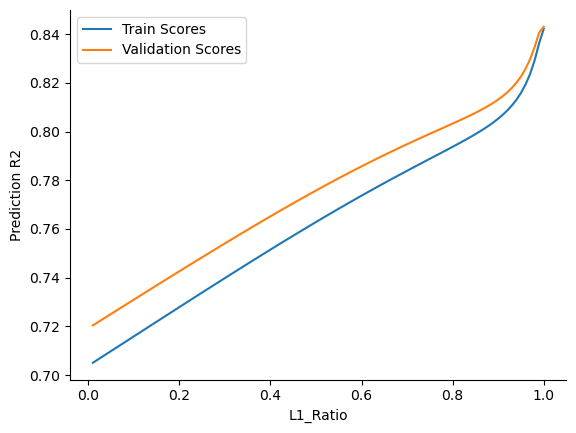

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(l1_ratios, train_scores, label="Train Scores")
ax.plot(l1_ratios, val_scores, label="Validation Scores")

ax.set_xlabel("L1_Ratio")
ax.set_ylabel("Prediction R2")

ax.spines[["top", "right"]].set_visible(False)
ax.legend()

Plot: kaip kinta modelio R² priklausomai nuo l1_ratio reikšmės (kai alpha = 1).

Mėlyna kreivė – treniravimo R².  
Oranžinė – validacijos R².

Matyti aiški tendencija:

- Kai l1_ratio arti 0 (modelis artimas Ridge), R² yra žemesnis.
- Didėjant l1_ratio, tiek treniravimo, tiek validacijos R² nuosekliai didėja.
- Geriausi rezultatai pasiekiami, kai l1_ratio artėja prie 1 (modelis tampa artimas Lasso).

Tai reiškia, kad šiame duomenų rinkinyje L1 komponentas (Lasso efektas) veikia geriau nei grynas Ridge.

Kadangi validacijos kreivė yra šiek tiek aukščiau nei treniravimo ir tarp jų nėra didelio atotrūkio, overfitting požymių nėra.

Bendra išvada:

Su alpha = 1 optimalus sprendimas šiame intervale yra l1_ratio arti 1, t. y. modelis turėtų būti labiau panašus į Lasso nei į Ridge.

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

l1_ratios = np.linspace(0.01, 1, 100)
alphas = 10 ** np.linspace(-3, 3, n_alphas)

param_grid = {"alpha": alphas, "l1_ratio": l1_ratios}

eNet_model = ElasticNet(max_iter=10000, random_state=2023)
grid = GridSearchCV(eNet_model, param_grid, scoring="r2", cv=5)

grid.fit(X_tr, y_train)


GridSearchCV(cv=5, estimator=ElasticNet(max_iter=10000, random_state=2023),
             param_grid={'alpha': array([1.00000000e-03, 1.07189132e-03, 1.14895100e-03, 1.23155060e-03,
       1.32008840e-03, 1.41499130e-03, 1.51671689e-03, 1.62575567e-03,
       1.74263339e-03, 1.86791360e-03, 2.00220037e-03, 2.14614120e-03,
       2.30043012e-03, 2.46581108e-03, 2.64308149e-03, 2.83309610e-03,
       3.03677112...
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
       0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
       0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55,
       0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66,
       0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77,
       0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88,
       0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99,
       1.  ])},
             scoring='r2')

Automatinė ElasticNet hiperparametrų paieška naudojant GridSearchCV.

l1_ratios = np.linspace(0.01, 1, 100)  
Tikrinami 100 skirtingų L1 ir L2 santykio variantų.

alphas = 10 ** np.linspace(-3, 3, n_alphas)  
Tikrinamos įvairaus stiprumo regularizacijos reikšmės nuo 0.001 iki 1000.

param_grid  
Apibrėžiamos visos galimos alpha ir l1_ratio kombinacijos.

ElasticNet(max_iter=10000, random_state=2023)  
Modelis su padidintu iteracijų skaičiumi (kad užtikrinti konvergenciją).

GridSearchCV(..., scoring="r2", cv=5)  
Kiekvienai parametrų kombinacijai atliekama 5-fold kryžminė validacija ir vertinamas R².

grid.fit(X_tr, y_train)  
Modelis:
- išbando visas alpha ir l1_ratio kombinacijas,
- kiekvienai apskaičiuoja vidutinį R² per 5 fold’us,
- išrenka geriausią parametrų derinį.


Tai profesionalus būdas vienu metu parinkti du hiperparametrus ir rasti optimalų balansą tarp modelio sudėtingumo ir stabilumo.

In [35]:
print(f"Best Params: {grid.best_params_}")
print(f"Best Score: {grid.best_score_}")

Best Params: {'alpha': 8.309941949353387, 'l1_ratio': 1.0}
Best Score: 0.8405407752173708


GridSearchCV parinko:

alpha ≈ 8.31  
l1_ratio = 1.0  

l1_ratio = 1.0 reiškia, kad optimalus modelis yra grynas Lasso (be Ridge komponento).

Best Score = 0.841  
Tai vidutinis 5-fold kryžminės validacijos R².

Interpretacija:

- Duomenyse L1 regularizacija veikia geriau nei L2.
- Reikalinga vidutinio stiprumo regularizacija (alpha ≈ 8.3).
- Modelis pasiekia apie 84 % paaiškinamos variacijos per validacijos rinkinius.

Kadangi optimalus sprendimas yra l1_ratio = 1, ElasticNet šiame duomenų rinkinyje natūraliai supaprastėja iki Lasso modelio.

In [36]:
eNet_final = ElasticNet(alpha=1.11, l1_ratio=1).fit(X_m, y)

eNet_final.score(X_m, y)

0.8434605427901631

Galutinis ElasticNet modelis su alpha = 1.11 ir l1_ratio = 1 (tai yra Lasso modelis) pasiekė:

R² = 0.843 (treniruotės duomenyse)

Tai reiškia, kad modelis paaiškina apie 84.3 % draudimo kainos variacijos.

Kadangi l1_ratio = 1, modelis faktiškai yra Lasso.  
Rezultatas labai panašus į anksčiau gautus Lasso ir Ridge modelių rezultatus (~0.84).

Išvada:

Modelis stabilus, regularizacija vidutinė, o prognozavimo kokybė išlieka aukšta.

In [37]:
eNet_final.score(X_te, y_test)

0.8474719972512876

Testavimo R² = 0.847 reiškia, kad galutinis ElasticNet (šiuo atveju – Lasso) modelis paaiškina apie 84.7 % draudimo kainos variacijos nematytuose duomenyse.

Kadangi treniravimo R² ≈ 0.843, o testavimo R² ≈ 0.847, modelis nėra pertreniruotas ir gerai generalizuojasi.

Rezultatas praktiškai sutampa su Ridge ir LassoCV modeliais, todėl galima daryti išvadą, kad šiame duomenų rinkinyje visi trys regularizuoti metodai duoda labai panašią ir stabilią prognozavimo kokybę.


## Elastic Net CV

In [38]:
from sklearn.linear_model import ElasticNetCV

alphas = 10 ** np.linspace(-3, 3, 200)
l1_ratios = np.linspace(.9, 1, 10) # .9, 1, 10

enet_model = ElasticNetCV(alphas=alphas, l1_ratio=l1_ratios, cv=5)

enet_model.fit(X_m, y)
print(enet_model.score(X_m, y))
print(enet_model.score(X_te, y_test))
print(enet_model.alpha_)
print(enet_model.l1_ratio_)

0.8434020595002002
0.8474294711924607
6.294988990221888
1.0


ElasticNetCV automatiškai parinko optimalų regularizacijos stiprumą ir L1/L2 santykį, naudodamas 5-fold kryžminę validaciją.

Gauti rezultatai:

Train R² = 0.843  
Modelis paaiškina apie 84.3 % kainos variacijos treniravimo duomenyse.

Test R² = 0.847  
Modelis paaiškina apie 84.7 % kainos variacijos nematytuose (testavimo) duomenyse.

alpha_ = 6.295  
Tai parinktas optimalus regularizacijos stiprumas. Reikšmė rodo vidutinę regularizaciją.

l1_ratio_ = 1.0  
Tai reiškia, kad geriausias sprendimas yra grynas Lasso (be Ridge komponento). Kitaip tariant, šiame duomenų rinkinyje L1 regularizacija duoda geriausią generalizaciją.

Bendra išvada:

ElasticNetCV praktiškai pasirinko Lasso modelį ir pasiekė stabilų rezultatą, labai panašų į RidgeCV ir LassoCV, todėl galima teigti, kad duomenims pakanka L1 regularizacijos, o papildomas L2 komponentas naudos nesuteikia.